

# Multivariate Normal Example
### OPIM 5641 — Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module4/MultivariateNormal_Example.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Mulivariate Normal Distributions
------------------------------------
**OPIM 5641: Business Decision Modeling - University of Connecticut**

We know that our stocks are correlated, so let's explore how we can sample from a multivariate normal distribution. That is, we shouldn't sample from the two distributions independently!

Note that in practice not all stock have normally distributed returns - but we ignore this for now and assume normality.

Here is some good background:
* https://brilliant.org/wiki/multivariate-normal-distribution/

# Let's try to use scipy
Check out this example:
* https://towardsdatascience.com/exploring-normal-distribution-with-jupyter-notebook-3645ec2d83f8#cc27

In [146]:
import pandas as pd

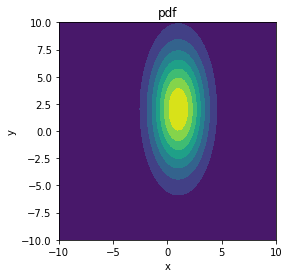

In [147]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

# this is a grid
x,y = np.meshgrid(np.linspace(-10,10,100),np.linspace(-10,10,100))
pos = np.dstack((x,y))
mean = np.array([1, 2])
cov  = np.array([[3,0],[0,15]])
#cov  = np.array([[1,0],[0,1]])
#cov  = np.array([[10,0],[0,10]])
rv = multivariate_normal(mean,cov)
z = rv.pdf(pos)

# make a plot
fig = plt.figure()
ax = fig.add_subplot(111,aspect='equal')
ax.contourf(x,y,z)
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('pdf')
plt.show()

# Let's try to use numpy
Easy to see in 2D - trickier to see in 5D or 10D! There are the same numbers are above.

Read the documentation here:
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.multivariate_normal.html

## Create and plot 2D sample

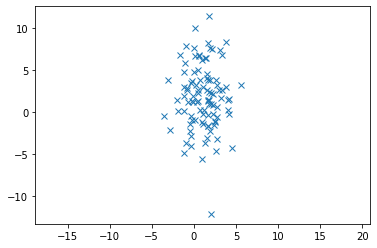

In [148]:
# now let's try to sample with numpy!
mean = [1, 2]
cov = [[3, 0], [0, 15]]  # diagonal covariance
# cov = [[100, 0], [0, 100]]  # diagonal covariance
x, y = np.random.multivariate_normal(mean, cov, 100).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

## Visualize each distribution

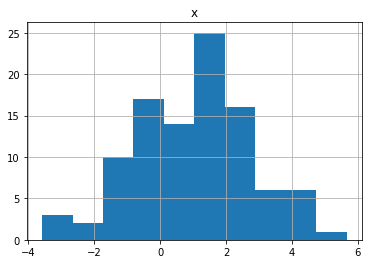

In [149]:
# make it a pandas dataframe and plot
x = pd.DataFrame(x)
x.hist()
plt.title('x')
plt.show()

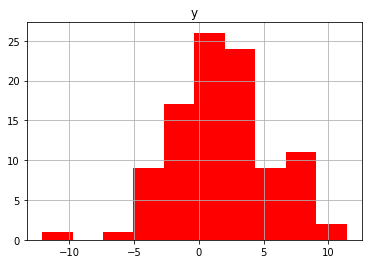

In [150]:
# make it a pandas dataframe and plot
y = pd.DataFrame(y)
y.hist(color='red')
plt.title('y')
plt.show()

# Try different values
Explore how values of 1 vs. 10 for each covariance would work... try to mix and match! You don't have to assume independence among distributions!!! Try values other than 0.

When does your code break? Think about why your code is breaking.

# Try it on Ms. Womack!
If you sample from the mulitvariate normal distribution with 5 stocks (5 means and 5 covariances) - what would the distributions of each one look like? What would the multivariate samples look like? Does it match what you see in that .csv file?

In [151]:
# here's computer and chemical from ms. womack


In [176]:
a1 = 0.009620 # top left (a,a)
a2 = -0.000657 # top right (a,b)
b1 = -0.000657 # bottom left (b,a)
b2 = 0.003631 # bottom right (b,b)

mu_1 = 0.020879
mu_2 = 0.012055
# notice how these variables are INDEPENENT! note the values of zero.

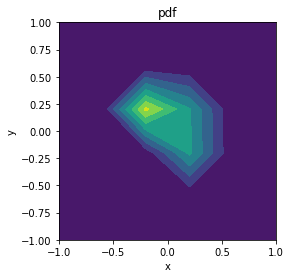

In [179]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

lower_val = -20
upper_val = 20

# this is a grid
x,y = np.meshgrid(np.linspace(lower_val,upper_val,100),np.linspace(lower_val,upper_val,100))
pos = np.dstack((x,y))
mean = np.array([mu_1, mu_2])
cov  = np.array([[a1,a2],[b1,b2]])
rv = multivariate_normal(mean,cov)
z = rv.pdf(pos)

# make a plot
fig = plt.figure()
ax = fig.add_subplot(111,aspect='equal')
ax.contourf(x,y,z)
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('pdf')
plt.show()

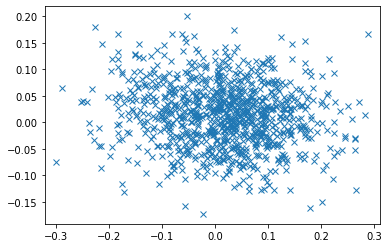

In [180]:
# now let's try to sample with numpy!
mean = [mu_1, mu_2]
cov = [[a1, a2], [b1, b2]]  # diagonal covariance
x, y = np.random.multivariate_normal(mean, cov, size=1000).T
plt.plot(x, y, 'x')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
plt.axis('equal')
plt.show()

Try to run a Monte Carlo simulation sampling from each stock randomly vs the multivariate normal distribution (includes covariance) - how do your results vary if you assume each of the five stocks gets the same allocation (20%)? Note that the example in this notebook only had covariances on the diagonal (covariance of X with X, covariance of Y with Y) and the rest of the values were 0... this means that X and Y are INDEPENDENT.

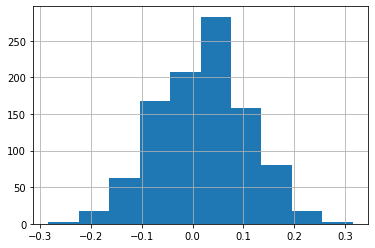

In [155]:
p1 = 0.9
p2 = 0.1

tmp = pd.DataFrame(x)
tmp.rename(columns={0:'x'}, inplace=True)
tmp['y'] = y
tmp['returns'] = p1*tmp['x'] + p2*tmp['y'] #40% in X, 60% in Y
tmp['returns'].hist()
plt.show()

In [156]:
tmp['returns'].describe()

count    1000.000000
mean        0.019572
std         0.088519
min        -0.283454
25%        -0.045447
50%         0.023089
75%         0.078177
max         0.315274
Name: returns, dtype: float64

# Try different values for `a` and `b`

## a1=100, a2=0, b1=0, b2=100
These are all different elements of the covariance matrix. The values a2 and b1 = 0 mean that these are COMPLETELY INDEPENDENT!

In [157]:
a1 = 100 # top left (a,a)
a2 = 0 # top right (a,b)
b1 = 0 # bottom left (b,a)
b2 = 100 # bottom right (b,b)

# notice how these variables are INDEPENENT! note the values of zero.

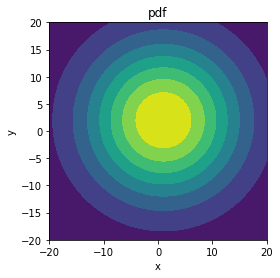

In [158]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

# this is a grid
x,y = np.meshgrid(np.linspace(-20,20,100),np.linspace(-20,20,100))
pos = np.dstack((x,y))
mean = np.array([1, 2])
cov  = np.array([[a1,a2],[b1,b2]])
rv = multivariate_normal(mean,cov)
z = rv.pdf(pos)

# make a plot
fig = plt.figure()
ax = fig.add_subplot(111,aspect='equal')
ax.contourf(x,y,z)
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('pdf')
plt.show()

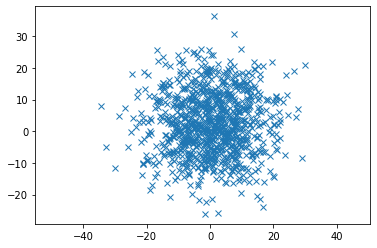

In [159]:
# now let's try to sample with numpy!
mean = [1, 2]
cov = [[a1, a2], [b1, b2]]  # diagonal covariance
x, y = np.random.multivariate_normal(mean, cov, size=1000).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

## Visualize each distribution

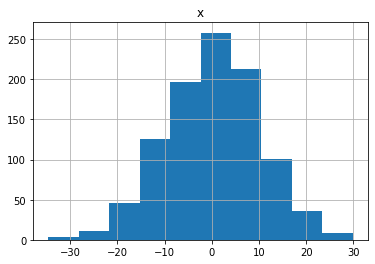

In [160]:
# make it a pandas dataframe and plot
x = pd.DataFrame(x)
x.hist()
plt.title('x')
plt.show()

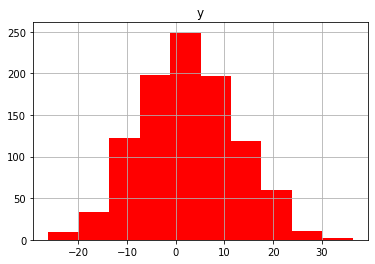

In [161]:
# make it a pandas dataframe and plot
y = pd.DataFrame(y)
y.hist(color='red')
plt.title('y')
plt.show()

## a1=100, a2=50, b1=50, b2=100
These are all different elements of the covariance matrix. The values a2 and b1 = 20 mean there is positive covariance! a2 and b1 should always be equal - and students should be able to explain why!

In [162]:
a1 = 100 # top left (a,a)
a2 = 50 # top right (a,b)
b1 = 50 # bottom left (b,a)
b2 = 100 # bottom right (b,b)

# notice how these variables are INDEPENENT! note the values of zero.

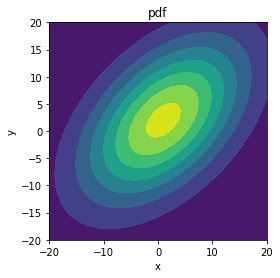

In [163]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

# this is a grid
x,y = np.meshgrid(np.linspace(-20,20,100),np.linspace(-20,20,100))
pos = np.dstack((x,y))
mean = np.array([1, 2])
cov  = np.array([[a1,a2],[b1,b2]])
rv = multivariate_normal(mean,cov)
z = rv.pdf(pos)

# make a plot
fig = plt.figure()
ax = fig.add_subplot(111,aspect='equal')
ax.contourf(x,y,z)
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('pdf')
plt.show()

Check out the sampling density plot... WHOA! Certain combinations of X and Y are more likely than others. It's not a perfect circle (bullseye).



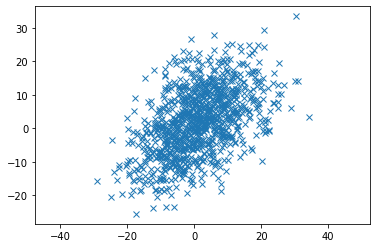

In [164]:
# now let's try to sample with numpy!
mean = [1, 2]
cov = [[a1, a2], [b1, b2]]  # diagonal covariance
x, y = np.random.multivariate_normal(mean, cov, size=1000).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

## Visualize each distribution

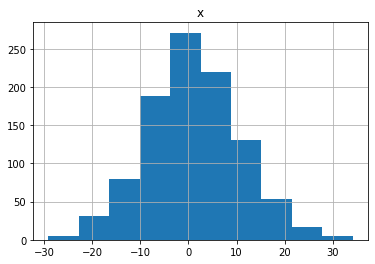

In [165]:
# make it a pandas dataframe and plot
x = pd.DataFrame(x)
x.hist()
plt.title('x')
plt.show()

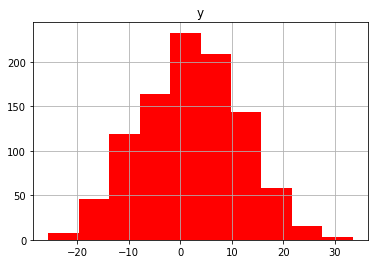

In [166]:
# make it a pandas dataframe and plot
y = pd.DataFrame(y)
y.hist(color='red')
plt.title('y')
plt.show()

## a1=100, a2=99, b1=99, b2=100
These are all different elements of the covariance matrix. The values a2 and b1 = 20 mean there is positive covariance! a2 and b1 should always be equal - and students should be able to explain why!

In [167]:
a1 = 100 # top left (a,a)
a2 = 99 # top right (a,b)
b1 = 99 # bottom left (b,a)
b2 = 100 # bottom right (b,b)

# notice how these variables are INDEPENENT! note the values of zero.

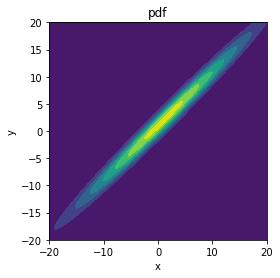

In [168]:
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt

# this is a grid
x,y = np.meshgrid(np.linspace(-20,20,100),np.linspace(-20,20,100))
pos = np.dstack((x,y))
mean = np.array([1, 2])
cov  = np.array([[a1,a2],[b1,b2]])
rv = multivariate_normal(mean,cov)
z = rv.pdf(pos)

# make a plot
fig = plt.figure()
ax = fig.add_subplot(111,aspect='equal')
ax.contourf(x,y,z)
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('pdf')
plt.show()

Check out the sampling density plot... WHOA! Certain combinations of X and Y are more likely than others. It's not a perfect circle (bullseye)... now it's a line!



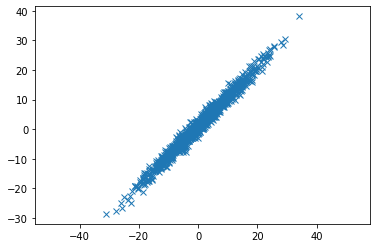

In [169]:
# now let's try to sample with numpy!
mean = [1, 2]
cov = [[a1, a2], [b1, b2]]  # diagonal covariance
x, y = np.random.multivariate_normal(mean, cov, size=1000).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

## Visualize each distribution

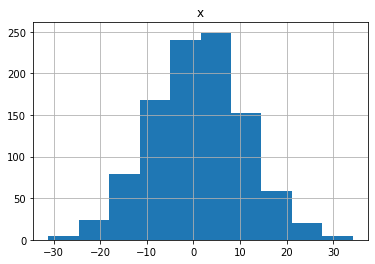

In [170]:
# make it a pandas dataframe and plot
x = pd.DataFrame(x)
x.hist()
plt.title('x')
plt.show()

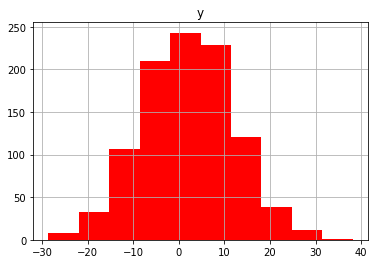

In [171]:
# make it a pandas dataframe and plot
y = pd.DataFrame(y)
y.hist(color='red')
plt.title('y')
plt.show()